In [1]:
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.colors as colors
pio.templates.default = "plotly_white"

In [2]:
df = pd.read_csv("Social_media_impact_on_life.csv", encoding= "latin= 1") 

In [3]:
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative
...,...,...,...,...,...,...,...,...,...,...,...
1700,701,20,Female,Undergraduate,Italy,4.7,TikTok,No,7.2,7.0,Positive
1701,702,23,Male,Graduate,Russia,6.8,Instagram,Yes,5.9,4.0,Negative
1702,703,21,Female,Undergraduate,China,5.6,WeChat,Yes,6.7,6.0,Negative
1703,704,24,Male,Graduate,Japan,4.3,Twitter,No,7.5,8.0,Positive


In [4]:
df1 = df     # Assigning due to EDA will be used later from no 69 cell

Data Inspection (Initial Exploration)

In [5]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


In [6]:
df.shape

(1705, 11)

In [7]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Overall_Impact'],
      dtype='str')

Data Types & Structure Analysis

In [8]:
df.info()            # Understand what kind of data each column holds 

<class 'pandas.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   str    
 3   Academic_Level                1705 non-null   str    
 4   Country                       1705 non-null   str    
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   str    
 7   Affects_Academic_Performance  1705 non-null   str    
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 212.3 KB


Statistical Summary

In [9]:
df.describe()             # math overview of numerical data 

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,1705.000000,1705.000000,1705.000000,1705.000000,1705.000000
mean,439.510264,20.848094,5.103636,6.598710,6.215132
std,267.058174,1.758557,1.677341,1.207045,1.282678
min,1.000000,18.000000,1.500000,3.800000,4.000000
25%,214.000000,19.000000,3.800000,5.600000,5.000000
50%,427.000000,21.000000,5.100000,6.600000,6.000000
75%,640.000000,22.000000,6.300000,7.500000,7.000000
max,1000.000000,24.000000,8.500000,9.600000,9.000000


Missing Value Analysis

In [10]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64

In [11]:
# percentage 

(df.isnull().sum() / len(df)) * 100

Student_ID                      0.0
Age                             0.0
Gender                          0.0
Academic_Level                  0.0
Country                         0.0
Avg_Daily_Usage_Hours           0.0
Most_Used_Platform              0.0
Affects_Academic_Performance    0.0
Sleep_Hours_Per_Night           0.0
Mental_Health_Score             0.0
Overall_Impact                  0.0
dtype: float64

Unique Value Analysis

In [12]:
df["Age"].unique()

array([21, 23, 22, 18, 24, 19, 20])

In [13]:
df['Age'].nunique()

7

In [14]:
df["Gender"].unique()


<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [15]:
df['Gender'].nunique()

2

In [16]:
df["Country"].unique()

<ArrowStringArray>
[      'Other',      'Canada',         'USA',       'India',   'Australia',
          'UK',     'Germany',  'Bangladesh',      'Brazil',       'Japan',
 ...
     'Lebanon',        'Iraq',       'Yemen',       'Syria', 'Afghanistan',
    'Pakistan',       'Nepal',      'Bhutan',   'Sri Lanka',    'Maldives']
Length: 111, dtype: str

In [17]:
df["Country"].nunique()

111

Initial Distribution Analysis

<Axes: xlabel='Age', ylabel='Count'>

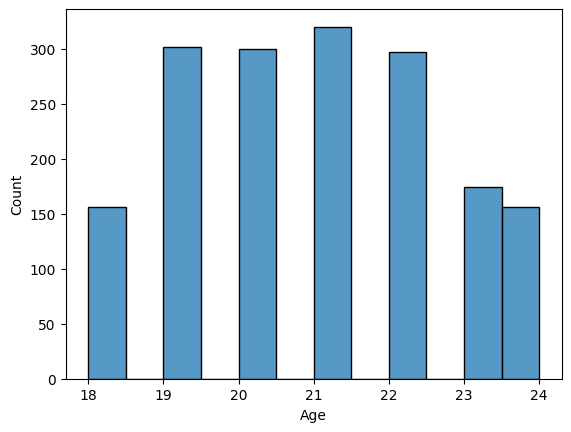

In [18]:
import seaborn as sns

sns.histplot(df['Age'])      

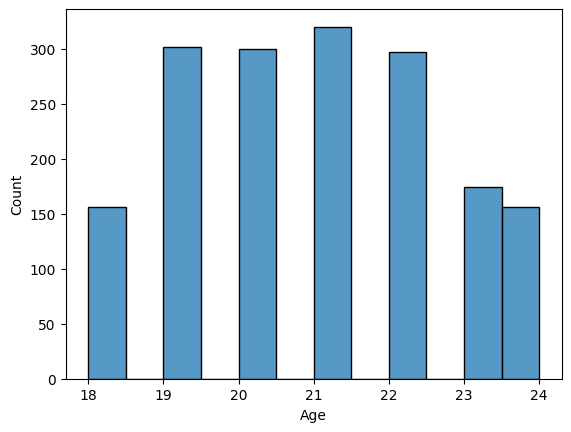

In [19]:
import matplotlib.pyplot as plt   # # in case of ipynb this doesn't need but .py it's needed , for best practice do it 
import seaborn as sns

sns.histplot(df['Age'])
plt.show()

Data Cleaning :

Handle Missing Values

In [20]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64

In [21]:
# (a) Drop missing rows (if small amount)

df.dropna(inplace=True)

In [22]:
# (b) Fill numerical values

# df['Age'].fillna(df['Age'].mean(), inplace=True)

In [23]:
# Fill categorical values

# df['Age'].fillna(df['Age'].mode()[0], inplace=True)

In [24]:
# Forward fill (time-series)

# df.ffill(inplace=True)

Remove Duplicates

In [25]:
df.duplicated().sum()   # check
df.drop_duplicates(inplace=True)

In [26]:
# Convert types

df['Age'] = df['Age'].astype(int)
# df['date'] = pd.to_datetime(df['date'])


In [27]:
# Clean numeric stored as text 

# df['Age'] = df['Age'].str.replace(',', '').astype(float)

In [28]:
# Standardize Text Data

df['Country'] = df['Country'].str.upper().str.strip()

In [29]:
df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,OTHER,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,OTHER,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,CANADA,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,OTHER,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,OTHER,7.5,Facebook,Yes,5.0,4.4,Negative
...,...,...,...,...,...,...,...,...,...,...,...
1700,701,20,Female,Undergraduate,ITALY,4.7,TikTok,No,7.2,7.0,Positive
1701,702,23,Male,Graduate,RUSSIA,6.8,Instagram,Yes,5.9,4.0,Negative
1702,703,21,Female,Undergraduate,CHINA,5.6,WeChat,Yes,6.7,6.0,Negative
1703,704,24,Male,Graduate,JAPAN,4.3,Twitter,No,7.5,8.0,Positive


In [30]:
df['Gender'] = df['Gender'].replace({
    'Male': 'M',
    'Female': 'F'
}, inplace=True) 

C:\Users\Monugya Borchetia\AppData\Local\Temp\ipykernel_20328\492735218.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Gender'] = df['Gender'].replace({


In [31]:
df


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,M,Undergraduate,OTHER,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,F,Undergraduate,OTHER,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,M,Graduate,CANADA,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,M,Undergraduate,OTHER,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,F,High School,OTHER,7.5,Facebook,Yes,5.0,4.4,Negative
...,...,...,...,...,...,...,...,...,...,...,...
1700,701,20,F,Undergraduate,ITALY,4.7,TikTok,No,7.2,7.0,Positive
1701,702,23,M,Graduate,RUSSIA,6.8,Instagram,Yes,5.9,4.0,Negative
1702,703,21,F,Undergraduate,CHINA,5.6,WeChat,Yes,6.7,6.0,Negative
1703,704,24,M,Graduate,JAPAN,4.3,Twitter,No,7.5,8.0,Positive


Handle Outliers

In [32]:
# IQR Method ( only with numeric column )

Q1 = df['Avg_Daily_Usage_Hours'].quantile(0.25)
Q3 = df['Avg_Daily_Usage_Hours'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Avg_Daily_Usage_Hours'] >= Q1 - 1.5*IQR) & 
        (df['Avg_Daily_Usage_Hours'] <= Q3 + 1.5*IQR)]

Rename Columns (Clean Naming) 

In [33]:
# df.columns = df.columns.str.lower().str.replace(' ', '_')
# or
# df.rename(columns={'Avg_Daily_Usage_Hours	': 'Avg-Daily-Usage-Hours	'}, inplace=True)

Remove Irrelevant Columns 

In [34]:
# df.drop(['unnecessary_column'], axis=1, inplace=True)

In [35]:
# Check & Fix Inconsistent Data

df['Country'] = df['Country'].str.title()

Final Validation

In [36]:
# Recheck everything

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    1705 non-null   int64  
 1   Age                           1705 non-null   int64  
 2   Gender                        1705 non-null   str    
 3   Academic_Level                1705 non-null   str    
 4   Country                       1705 non-null   str    
 5   Avg_Daily_Usage_Hours         1705 non-null   float64
 6   Most_Used_Platform            1705 non-null   str    
 7   Affects_Academic_Performance  1705 non-null   str    
 8   Sleep_Hours_Per_Night         1705 non-null   float64
 9   Mental_Health_Score           1705 non-null   float64
 10  Overall_Impact                1705 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 205.9 KB


In [37]:
df.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

Data transformation/Feature engineering

In [39]:
# Feature Creation (New Columns)

# Extract year from date
# df['year'] = df['order_date'].dt.year

# Create profit column
# df['profit'] = df['revenue'] - df['cost']


In [40]:
# Feature Transformation (Modify Existing Data)

# import numpy as np
# df['income_log'] = np.log(df['income']) 

In [41]:
# Square / power transformation
# df['area_squared'] = df['area'] ** 2

In [42]:
# Encoding Categorical Variables

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [43]:
# One-Hot Encoding (nominal data)

df = pd.get_dummies(df, columns=['Country'], drop_first=True)

In [44]:
# Feature Scaling (Normalization / Standardization) 

# Standardization (mean = 0, std = 1)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Mental_Health_Score','Avg_Daily_Usage_Hours']] = scaler.fit_transform(df[['Mental_Health_Score','Avg_Daily_Usage_Hours']])

In [45]:
# Normalization (0 to 1 range)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['Mental_Health_Score','Avg_Daily_Usage_Hours']] = scaler.fit_transform(df[['Mental_Health_Score','Avg_Daily_Usage_Hours']])

In [46]:
# Binning (Discretization)

# Convert continuous → categories

df['Usage_Level'] = pd.cut(
    df['Avg_Daily_Usage_Hours'],
    bins=[0, 3, 6, 10],
    labels=['Low', 'Medium', 'High']
)

In [47]:
# Handling Skewed Data

import numpy as np

df['Avg_Daily_Usage_Hours'] = np.log1p(df['Avg_Daily_Usage_Hours'])

In [48]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact,...,Country_Uk,Country_Ukraine,Country_Uruguay,Country_Usa,Country_Uzbekistan,Country_Vatican City,Country_Venezuela,Country_Vietnam,Country_Yemen,Usage_Level
0,232,21,1,Undergraduate,0.305382,Facebook,No,6.7,0.56,Neutral,...,False,False,False,False,False,False,False,False,False,Low
1,564,23,0,Undergraduate,0.014185,LinkedIn,No,8.6,0.72,Positive,...,False,False,False,False,False,False,False,False,False,Low
2,788,22,1,Graduate,0.366625,Instagram,No,6.7,0.60,Neutral,...,False,False,False,False,False,False,False,False,False,Low
3,686,18,1,Undergraduate,0.579818,Snapchat,Yes,5.4,0.26,Negative,...,False,False,False,False,False,False,False,False,False,Low
4,608,24,0,High School,0.619039,Facebook,Yes,5.0,0.08,Negative,...,False,False,False,False,False,False,False,False,False,Low


In [49]:
# Extract Features from Date

# df['month'] = df['order_date'].dt.month
# df['day'] = df['order_date'].dt.day
# df['weekday'] = df['order_date'].dt.weekday

In [50]:
# Feature Selection (Keep Important Features)

# Remove unnecessary features

# df.drop(['irrelevant_column'], axis=1, inplace=True)

# OR using correlation:

# df.corr()

In [51]:
# Interaction Features (Advanced)

# Combine features

# df['income_per_age'] = df['income'] / df['age']

EXPLORATORY DATA ANALYSIS (EDA)

In [52]:
# Analyze how social media usage impacts students’

# Academic performance
# Sleep
# Mental health

In [53]:
# STEP 1: Basic Overview
# Dataset Info:
# Rows: 1705
# Columns: 11
# Columns:
# Age, Gender, Country
# Usage Hours
# Sleep Hours
# Mental Health Score
# Academic Impact
# Overall Impact

# Clean dataset (no missing values)

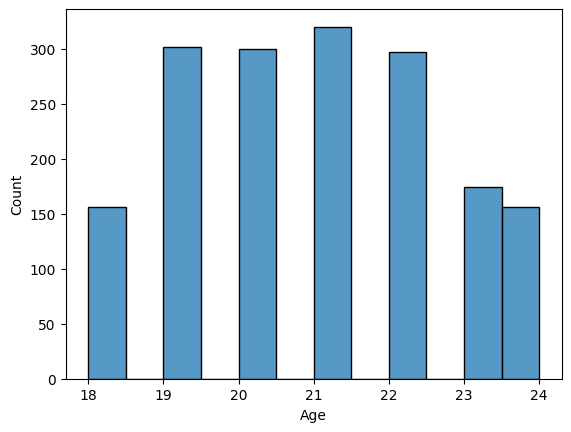

In [67]:
# 1) Univariate Analysis

# Question: What age group dominates?
# Age Distribution

sns.histplot(df1['Age'])
plt.show()



# Most students are between 18–24
# Dataset mainly represents young students

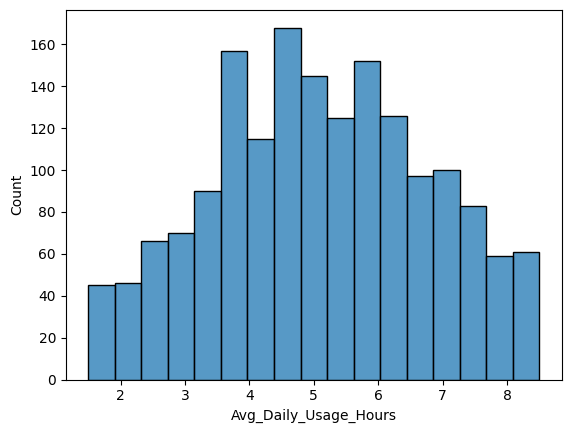

In [96]:
# Daily Usage Hours

sns.histplot(df1['Avg_Daily_Usage_Hours'])
plt.show()



# Most users spend 3–6 hours/day
# Heavy usage is common

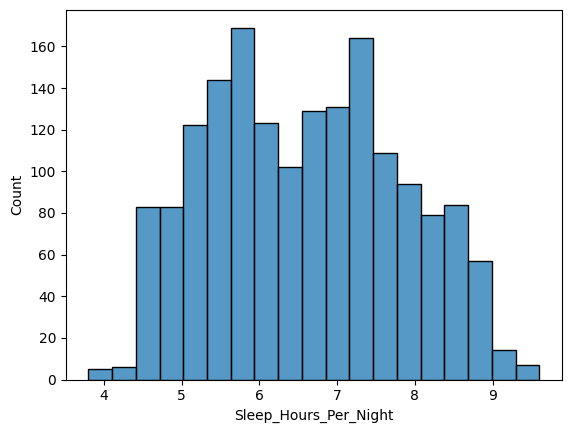

In [61]:
# Sleep Hours

sns.histplot(df1['Sleep_Hours_Per_Night'])
plt.show()


# Majority sleep 5–7 hours
# Slight sleep deprivation trend 

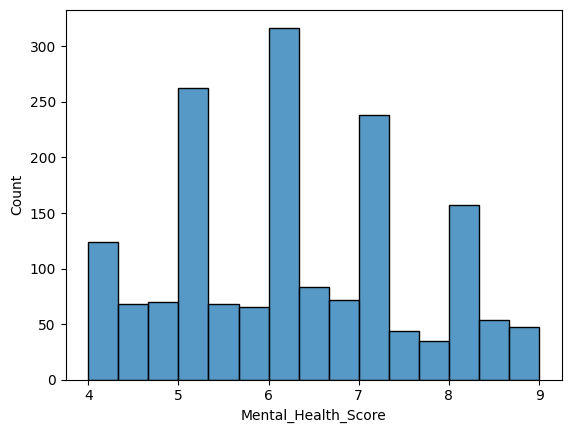

In [60]:
# Mental Health Score

sns.histplot(df1['Mental_Health_Score'])
plt.show()


# Scores mostly between 5–8
# Moderate mental health overall

In [ ]:
# line 

# fig = px.line(sales_by_month, 
#               x='Order Month', 
#               y='Sales', 
#               title='Monthly Sales Analysis') 

# fig.show()



# bar 

# fig = px.bar(sales_by_subcategory, x= 'Sub-Category', y = 'Sales', title= "Sales analysis by sub category")

# fig.show()

In [63]:
# Categorical Analysis
# Gender

df1['Gender'].value_counts()

# Check balance of male/female 

Gender
M    878
F    827
Name: count, dtype: int64

In [65]:
# Most Used Platform

df1['Most_Used_Platform'].value_counts()


# Dominant platforms: Instagram, TikTok

Most_Used_Platform
Instagram    389
TikTok       295
Facebook     256
LinkedIn     176
Twitter      170
YouTube      165
Snapchat     149
WhatsApp      54
WeChat        15
LINE          12
KakaoTalk     12
VKontakte     12
Name: count, dtype: int64

In [66]:
# Academic Impact

df1['Affects_Academic_Performance'].value_counts()

# Positive / Negative / Neutral 

Affects_Academic_Performance
Yes    1011
No      694
Name: count, dtype: int64

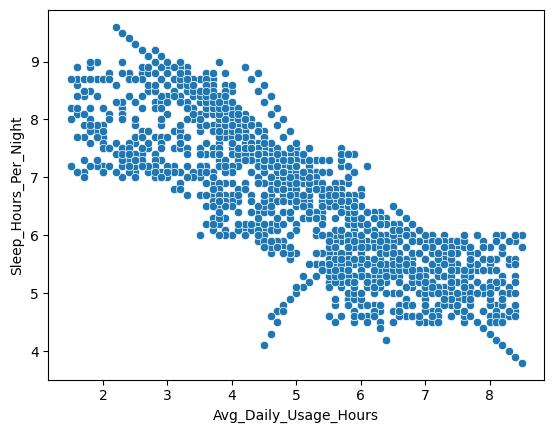

In [77]:
# 2) Bivariate Analysis

# Usage vs Sleep

sns.scatterplot(x='Avg_Daily_Usage_Hours',
                y='Sleep_Hours_Per_Night',
                data=df1)
plt.show()

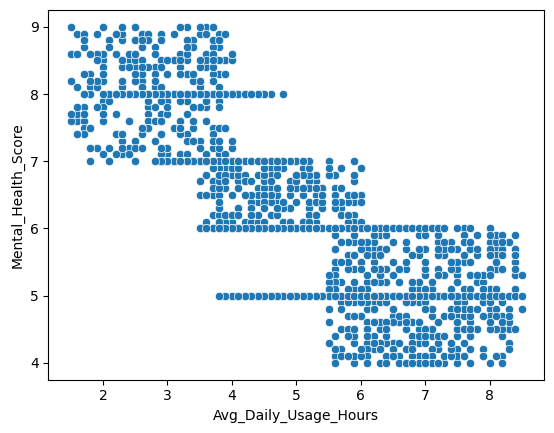

In [71]:
# Usage vs Mental Health

sns.scatterplot(x='Avg_Daily_Usage_Hours',
                y='Mental_Health_Score',
                data=df1)
plt.show()


# Higher usage → lower mental health (trend)

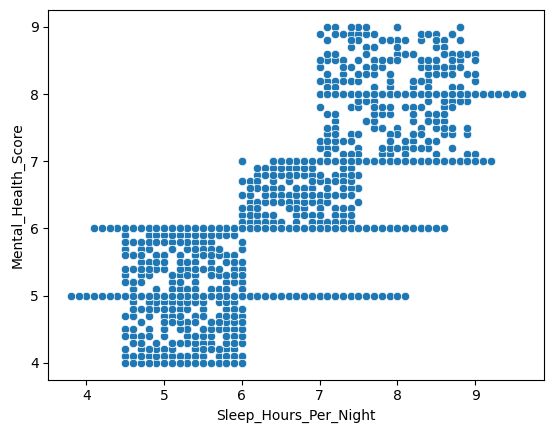

In [72]:
# Sleep vs Mental Health

sns.scatterplot(x='Sleep_Hours_Per_Night',
                y='Mental_Health_Score',
                data=df1)
plt.show()


# More sleep → better mental health
# Strong positive relationship 

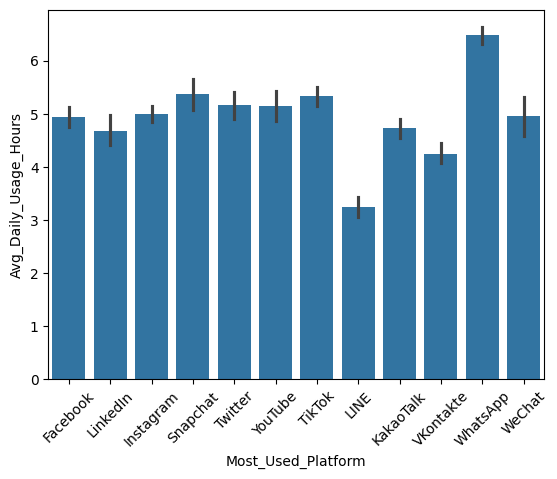

In [74]:
# Platform vs Usage

sns.barplot(x='Most_Used_Platform',
            y='Avg_Daily_Usage_Hours',
            data=df1)
plt.xticks(rotation=45)
plt.show()


# Which platform consumes most time : Whatsapp

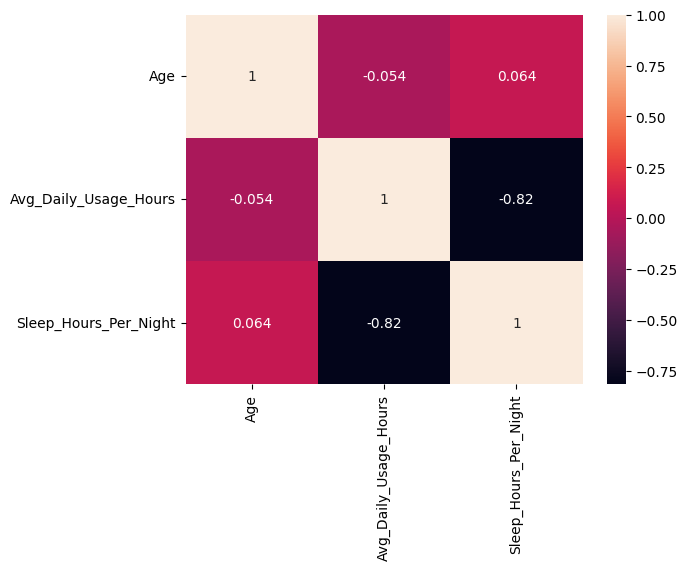

In [81]:
# 3) Correlation Analysis 

sns.heatmap(df1[['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night']].corr(), annot=True)
plt.show()

# Usage vs Sleep → Negative
# Sleep vs Mental Health → Positive
# Usage vs Mental Health → Negative

# This confirms behavioral patterns

In [84]:
# Group Analysis (VERY IMPORTANT)
# Academic Impact vs Usage

df1.groupby('Affects_Academic_Performance')['Avg_Daily_Usage_Hours'].mean()

# Students affected negatively → higher usage

Affects_Academic_Performance
No     4.070029
Yes    5.813155
Name: Avg_Daily_Usage_Hours, dtype: float64

In [85]:
# Gender vs Usage

df1.groupby('Gender')['Avg_Daily_Usage_Hours'].mean()

# Compare behavior differences

Gender
F    5.155260
M    5.055011
Name: Avg_Daily_Usage_Hours, dtype: float64

In [87]:
# Country-wise Usage

df1.groupby('Country')['Avg_Daily_Usage_Hours'].mean().sort_values(ascending=False)

# Identify highest usage countries 

Country
UAE               6.725000
MEXICO            6.422222
ECUADOR           6.300000
CZECH REPUBLIC    6.100000
THAILAND          5.900000
                    ...   
BOLIVIA           2.400000
BOSNIA            2.400000
SLOVAKIA          2.300000
SOUTH AFRICA      2.300000
SWEDEN            2.000000
Name: Avg_Daily_Usage_Hours, Length: 111, dtype: float64

In [89]:
# Overall Impact Distribution

df['Overall_Impact'].value_counts()

# Positive / Negative / Neutral breakdown

Overall_Impact
Negative    939
Positive    499
Neutral     267
Name: count, dtype: int64

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

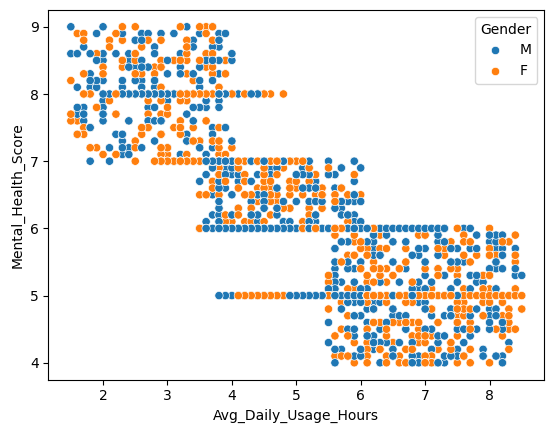

In [91]:
# Multivariate Analysis

# multivariate analysis, which means:
# Studying relationship between more than 2 variables at the same time

sns.scatterplot(x='Avg_Daily_Usage_Hours',
                y='Mental_Health_Score',
                hue='Gender',
                data=df1)

In [92]:
# Key Findings : 

# Major Insights:

# High social media usage (3–6 hrs/day) is common
# Increased usage reduces sleep hours
# Lower sleep leads to poorer mental health
# Heavy users tend to have negative academic impact
# Mental health improves with better sleep 

In [93]:
# Business / Real-Life Interpretation

# Social media overuse can harm student performance
# Sleep is a critical factor linking usage and mental health
# Awareness programs could help reduce overuse 

In [94]:
# Final Conclusion

# Social media usage has a significant negative impact on students when overused, particularly affecting sleep and mental health, 
# which in turn influences academic performance.

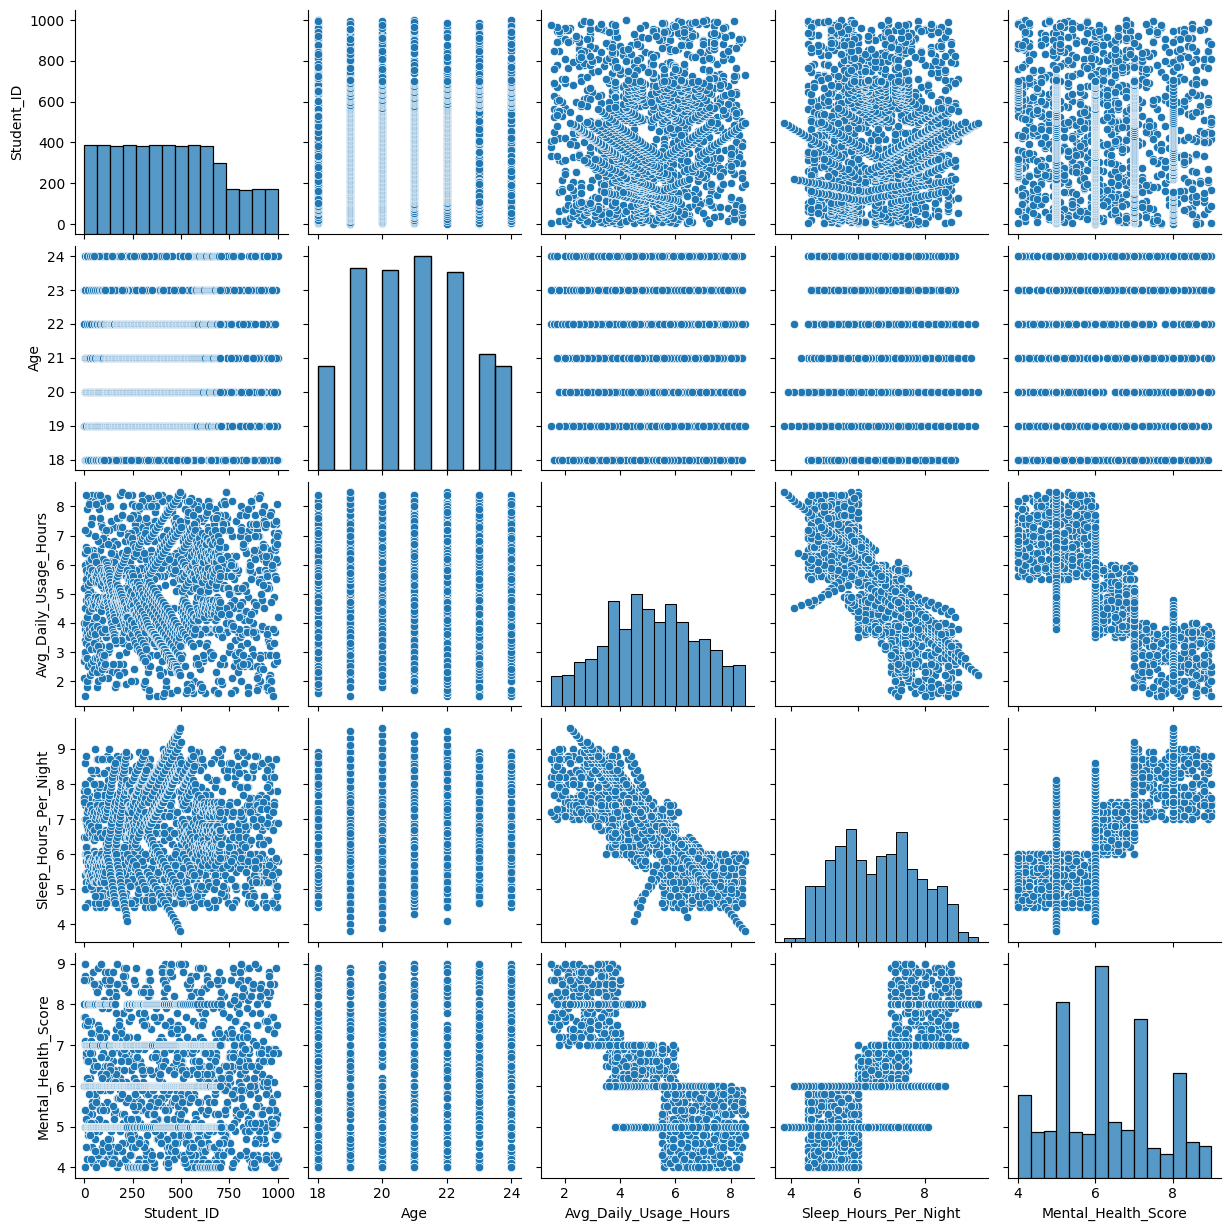

In [97]:
# Pairplot (Full Relationship Overview)

sns.pairplot(df1)
plt.show()

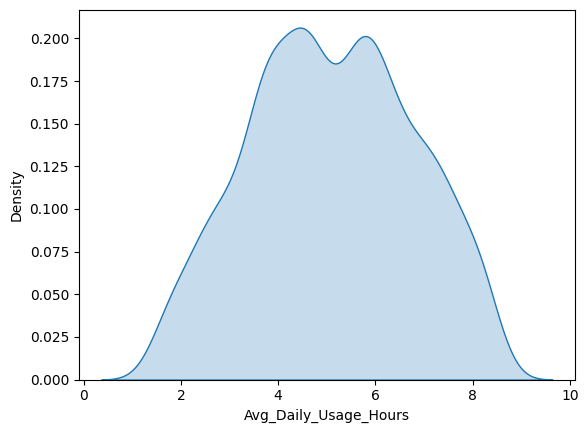

In [105]:
# KDE Plot (Distribution Shape – Smooth)

sns.kdeplot(df1['Avg_Daily_Usage_Hours'], fill=True)
plt.show()

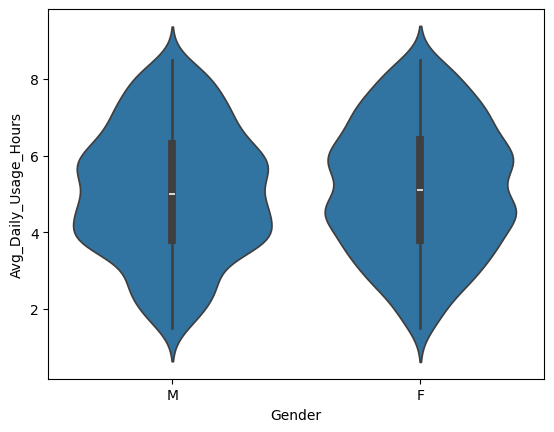

In [106]:
# Violin Plot (Advanced Distribution)

# Combination of boxplot + KDE

sns.violinplot(x='Gender', y='Avg_Daily_Usage_Hours', data=df1)
plt.show()

# Shows distribution + spread + density

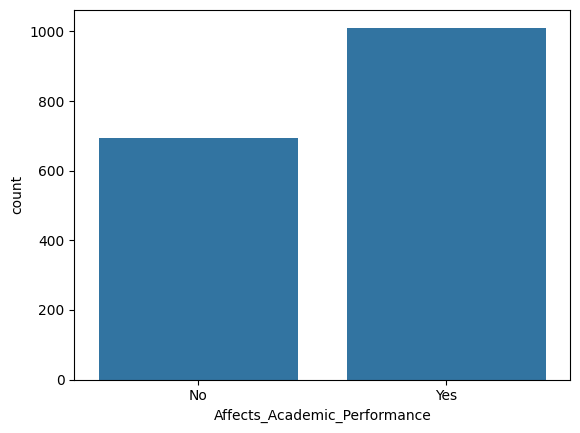

In [107]:
# Count Plot (You only partially used)
# Use properly for all categorical columns

sns.countplot(x='Affects_Academic_Performance', data=df1)
plt.show()

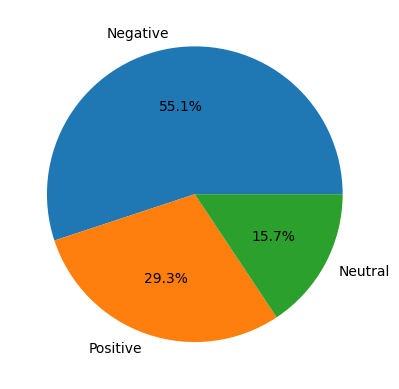

In [108]:
# Pie Chart (Optional but Good for Reports)

df1['Overall_Impact'].value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

# Good for presentation (non-technical audience)

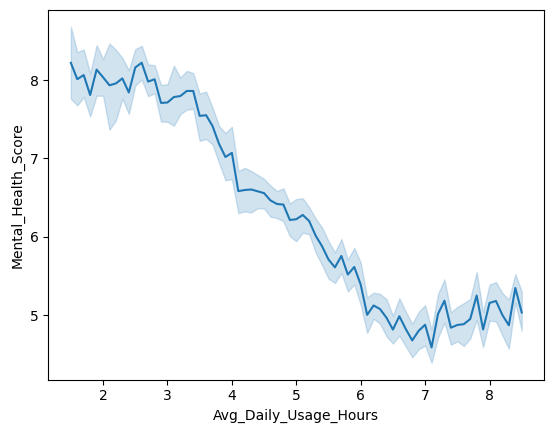

In [109]:
# Line Plot (Trend Visualization)

# Especially if time-based or ordered data

sns.lineplot(x='Avg_Daily_Usage_Hours',
             y='Mental_Health_Score',
             data=df1)
plt.show()

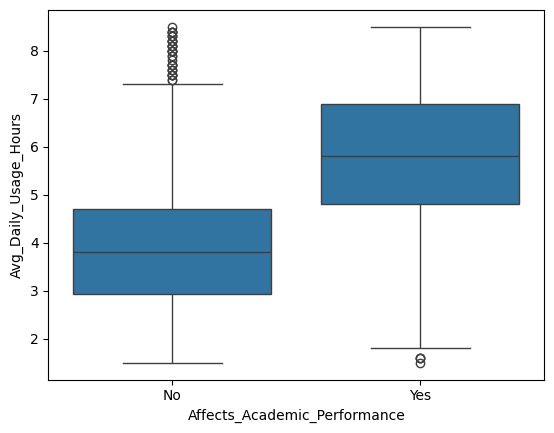

In [110]:
# Boxplot by Category

# You only used simple boxplot

sns.boxplot(x='Affects_Academic_Performance',
            y='Avg_Daily_Usage_Hours',
            data=df1)
plt.show()

# Shows how categories differ 

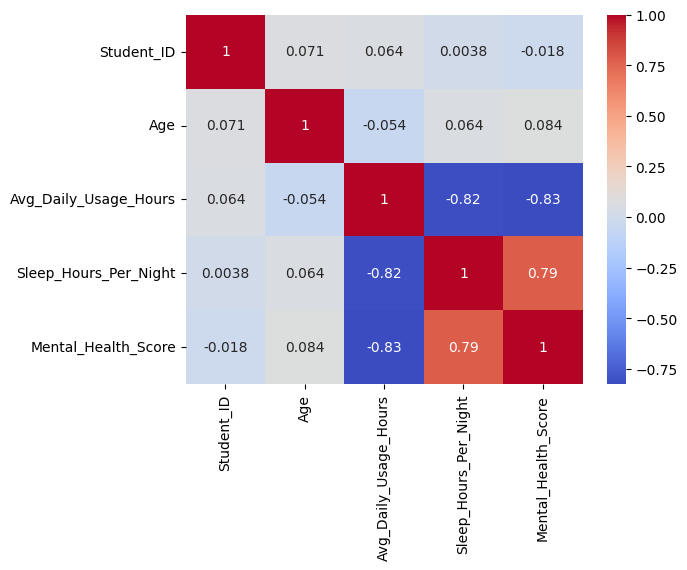

In [111]:
# Heatmap (Improved Version)

corr = df1.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
sales_profit_by_segment = df1.groupby('Segment').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index() 

color_palette = colors.qualitative.Pastel

fig = go.Figure()

fig.add_trace(go.Bar(x=sales_profit_by_segment['Segment'], 
                     y=sales_profit_by_segment['Sales'], 
                     name='Sales',
                     marker_color=color_palette[0]))

fig.add_trace(go.Bar(x=sales_profit_by_segment['Segment'], 
                     y=sales_profit_by_segment['Profit'], 
                     name='Profit',
                     marker_color=color_palette[1]))

fig.update_layout(title='Sales and Profit Analysis by Customer Segment',
                  xaxis_title='Customer Segment', yaxis_title='Amount')

fig.show() 